In [19]:
import json
import numpy as np

In [7]:
with open("/data2/jsonl/val_ground_truth.json", "r") as f:
    val_gt = json.load(f)
    
with open("/data2/jsonl/validation_sents_v3.json", "r") as f:
    val_sents = json.load(f)

In [11]:
from cer_wer import _cer_and_wer
cer, wer, wer_per_sentence = _cer_and_wer(val_gt, val_sents)

In [20]:
cer_per_sentence = np.load('/data2/perf_metrics/cer_per_sentence.npy')

In [24]:
from scipy.stats import pearsonr
pearsonr(cer_per_sentence, wer_per_sentence)

PearsonRResult(statistic=np.float64(0.7948676985518882), pvalue=np.float64(1.078147560457745e-192))

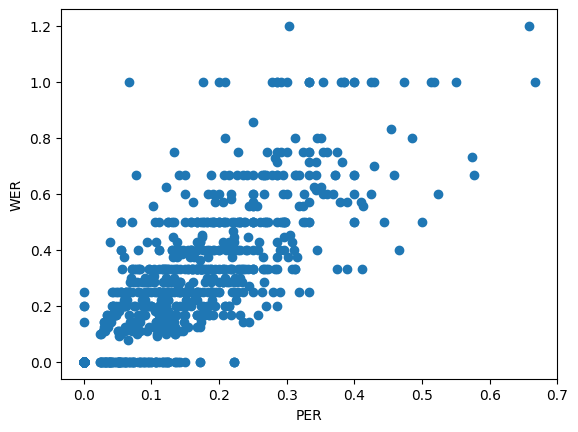

NameError: name 'LogNorm' is not defined

<Figure size 600x500 with 0 Axes>

In [31]:
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
plt.scatter(cer_per_sentence, wer_per_sentence)
plt.xlabel("PER")
plt.ylabel("WER")
plt.show()
plt.figure(figsize=(6,5))
plt.hist2d(cer_per_sentence, wer_per_sentence, bins=50, cmap="viridis",  norm=LogNorm())
plt.colorbar(label="Counts")
plt.xlabel("PER")
plt.ylabel("WER")
plt.title("2D Histogram of PER vs WER")
plt.show()